<a href="https://colab.research.google.com/github/chalakafernando4/quantum-random-number-generator/blob/main/qrng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a True Quantum Random Number Generator (QRNG)

Welcome to this interactive quantum simulation! In this notebook, we are going to build a foundational quantum algorithm: a True Quantum Random Number Generator.

## The Problem with Classical Randomness

If you ask a classical computer (like the one you are using right now) to pick a random number between 1 and 10, it doesn't actually do anything "random." It uses a mathematical algorithm called a **Pseudo-Random Number Generator (PRNG)**. It takes a "seed" value (often the exact current time on your system's clock) and runs it through a complex, deterministic formula.

If you know the exact starting conditions, you can perfectly predict the classical "random" number. It is an illusion.

## The Quantum Solution: Superposition

Quantum computers operate on entirely different laws of physics. Instead of deterministic math, they leverage the inherent unpredictability of the quantum realm to generate **true randomness**.

To do this, we use a concept called **Superposition**.

1. We start with a single qubit in its lowest energy state, represented as $|0\rangle$.
2. We apply a microwave pulse to the qubit, known as a **Hadamard Gate ($H$)**.

The Hadamard gate places the qubit into a perfect, equal superposition of both 0 and 1 simultaneously. Mathematically, the state of our qubit is now defined as:

$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

The value $\frac{1}{\sqrt{2}}$ represents the probability amplitude. In quantum mechanics, the actual probability of an outcome is the square of its amplitude. If we square $\frac{1}{\sqrt{2}}$, we get exactly $\frac{1}{2}$, or **50%**.

## The Measurement (Collapsing the Wave Function)

Right now, the qubit is hovering in that 50/50 state. But the moment we force the quantum computer to **measure** the qubit, the laws of physics dictate that it must pick a side. The superposition collapses, and the universe essentially flips a coin, resulting in a perfectly random `0` or `1`.

In the code block below, we will use **IBM's Qiskit** framework to:

* Initialize a qubit.
* Apply the Hadamard gate to create the superposition.
* Measure the outcome 1,000 times (called "shots").
* Plot the results to prove the 50/50 probability distribution.

---

In [1]:
!pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.7 MB/s eta 0:00:00


#The Visual QRNG Code

Rolling the quantum dice 1000 times...

--- Results ---
0 was measured 500 times.
1 was measured 500 times.


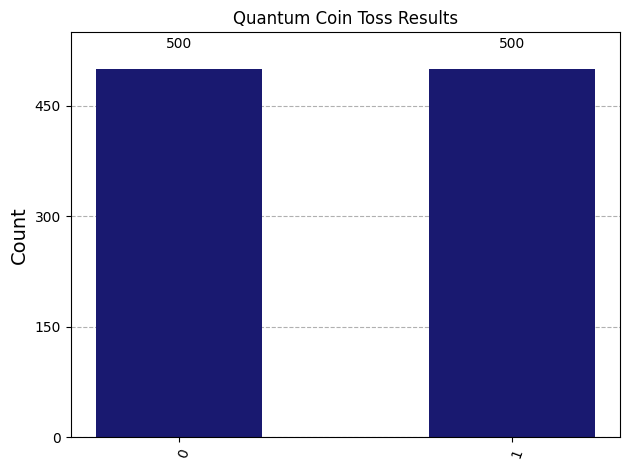

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def generate_visual_qrng(num_bits=1000):
    """Generates random bits and plots the probability distribution."""
    print(f"Rolling the quantum dice {num_bits} times...")

    # 1. Build the circuit (1 Qubit, 1 Classical Bit)
    qc = QuantumCircuit(1, 1)
    qc.h(0)          # Apply Hadamard to create superposition
    qc.measure(0, 0) # Measure the collapse

    # 2. Run the simulation
    simulator = AerSimulator()
    job = simulator.run(qc, shots=num_bits)
    result = job.result()
    counts = result.get_counts(qc)

    # 3. Print the raw data
    print("\n--- Results ---")
    print(f"0 was measured {counts.get('0', 0)} times.")
    print(f"1 was measured {counts.get('1', 0)} times.")

    # 4. Generate and display the histogram
    display(plot_histogram(counts, title="Quantum Coin Toss Results", color='midnightblue'))

# Run the function
generate_visual_qrng(1000)